In [40]:
import numpy as np
import numpy.random as  rd
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [41]:
df=pd.read_csv('countrylanguage.csv')

In [42]:
df

,CountryCode,Language,IsOfficial,Percentage
0,ABW,Dutch,T,5.3
1,ABW,English,F,9.5
2,ABW,Papiamento,F,76.7
3,ABW,Spanish,F,7.4
4,AFG,Balochi,F,0.9
...,...,...,...,...
979,ZMB,Tongan,F,11.0
980,ZWE,English,T,2.2
981,ZWE,Ndebele,F,16.2
982,ZWE,Nyanja,F,2.2


In [43]:
df.columns

Index(['CountryCode', 'Language', 'IsOfficial', 'Percentage'], dtype='object')

# Data cleaning

In [44]:
df.duplicated().any()

np.False_

In [45]:
df.isnull().sum()

CountryCode    0
Language       0
IsOfficial     0
Percentage     0
dtype: int64

In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 984 entries, 0 to 983
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   CountryCode  984 non-null    object 
 1   Language     984 non-null    object 
 2   IsOfficial   984 non-null    object 
 3   Percentage   984 non-null    float64
dtypes: float64(1), object(3)
memory usage: 30.9+ KB


# Data Analysis

# 1. How may langauges are there in our data set

In [47]:
df['Language'].shape[0]

984

# 2. How many country codes are there in our datset

In [48]:
df['CountryCode'].shape[0]

984

# 3.How many lang have in Each Country Code 

In [49]:
lang=df.groupby('CountryCode')['Language'].count()
lang
# lang=pd.pivot_table(df,index=['CountryCode'],aggfunc=['count'],values='Language')
# lang

CountryCode
ABW     4
AFG     5
AGO     9
AIA     1
ALB     3
       ..
YEM     2
YUG     6
ZAF    11
ZMB     6
ZWE     4
Name: Language, Length: 233, dtype: int64

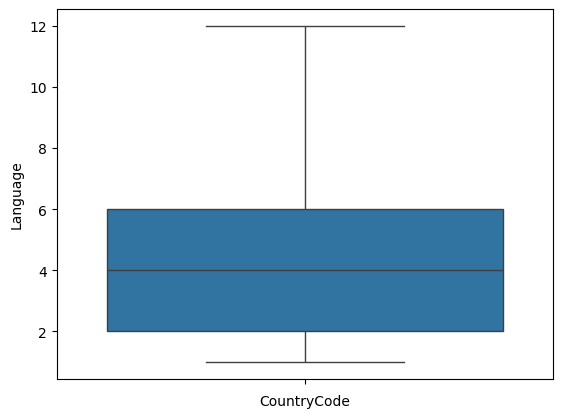

In [50]:
sns.boxplot(lang)
plt.xlabel('CountryCode')
plt.xticks(rotation=90)
plt.show()

Observation:
1. Comparing all Contry codes  ZAF having  more languages
2.  most of the countreis know  more languages

# 4. How many languages are isofficial

In [51]:
cnt=df.loc[df['IsOfficial']=='T'].count()
cnt

CountryCode    238
Language       238
IsOfficial     238
Percentage     238
dtype: int64

# 5.How many language having high percentage

In [52]:
a=df.groupby('Language')['Percentage'].max().count()
a

np.int64(457)

# 6. which languages are high percentage

In [53]:
high=df.groupby('Language')['Percentage'].max().sort_values(ascending=False)
high

Language
Spanish        100.0
Italian        100.0
Arabic         100.0
Crioulo        100.0
English        100.0
               ...  
Pitcairnese      0.0
Saame            0.0
Soqutri          0.0
Sinaberberi      0.0
Tokelau          0.0
Name: Percentage, Length: 457, dtype: float64

# 7. How many languages are not official

In [54]:
not_official=df[df['IsOfficial']=='F']['Language'].nunique()
not_official

430

# 8. which languags having least percentage

In [55]:
least=df.groupby('Language')['Percentage'].min()
least

Language
Abhyasi          1.7
Acholi           4.4
Adja            11.1
Afar             4.3
Afrikaans        9.5
                ... 
Zapotec          0.6
Zenaga           1.2
Zhuang           1.4
Zulu             2.0
[South]Mande     7.7
Name: Percentage, Length: 457, dtype: float64

# 9. how many languages are  in least percentage

In [56]:
lang=df.groupby('Language')['Percentage'].min().count()
lang

np.int64(457)

# 10. which langague are  high percentage

In [57]:
high=df.groupby('Language')['Percentage'].max().sort_values().head(1)
high

Language
Ainu    0.0
Name: Percentage, dtype: float64

# 11. which language having least percentage

In [58]:
least=df.groupby('Language')['Percentage'].min().sort_values().head(1)
least

Language
Urdu    0.0
Name: Percentage, dtype: float64

# 12. Languages spoken in the highest number of countries

In [59]:
lang_country_count = df.groupby("Language")["CountryCode"].nunique().sort_values(ascending=False).head(10)
lang_country_count

Language
English           60
Arabic            33
Spanish           28
French            25
German            19
Chinese           19
Russian           17
Italian           15
Creole English    14
Portuguese        12
Name: CountryCode, dtype: int64

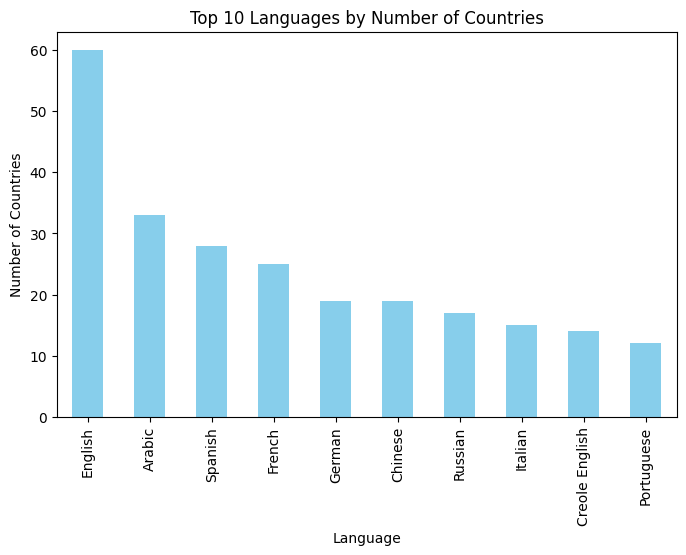

In [60]:
lang_country_count.plot(kind="bar", figsize=(8,5), color="skyblue")
plt.title("Top 10 Languages by Number of Countries")
plt.ylabel("Number of Countries")
plt.show()

# Observation

* English, French, Spanish, Arabic appear in the highest number of countries.

# 13. Distribution of languages across IsOfficial

In [61]:
continent_lang = df.groupby("IsOfficial")["Language"].nunique().sort_values(ascending=False)
continent_lang

IsOfficial
F    430
T    102
Name: Language, dtype: int64

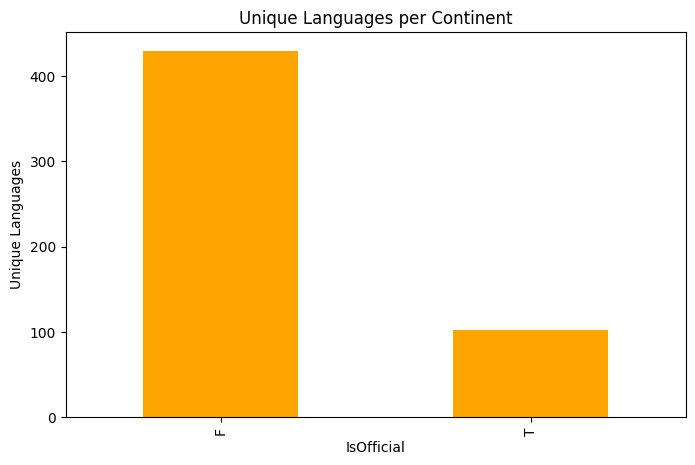

In [62]:
continent_lang.plot(kind="bar", color="orange", figsize=(8,5))
plt.title("Unique Languages per Continent")
plt.ylabel("Unique Languages")
plt.show()


# Observation

* Africa has the highest number of unique languages, followed by Asia.

# 14. Countries with the highest number of official languages

In [63]:
df["IsOfficial"].unique()

array(['T', 'F'], dtype=object)

In [64]:
# If Official column uses T/F
official_langs = df[df["IsOfficial"].isin(["Yes", "T", "True", 1])]
official_langs 

,CountryCode,Language,IsOfficial,Percentage
0,ABW,Dutch,T,5.3
5,AFG,Dari,T,32.1
6,AFG,Pashto,T,52.4
18,AIA,English,T,0.0
19,ALB,Albaniana,T,97.9
...,...,...,...,...
963,ZAF,Afrikaans,T,14.3
964,ZAF,English,T,8.5
972,ZAF,Xhosa,T,17.7
973,ZAF,Zulu,T,22.7


In [65]:
official_langs_count=official_langs.groupby("CountryCode")["Language"].nunique().sort_values(ascending=False).head(10)
official_langs_count

CountryCode
CHE    4
ZAF    4
BEL    3
PER    3
LUX    3
BOL    3
VUT    3
SGP    3
CYP    2
CAN    2
Name: Language, dtype: int64

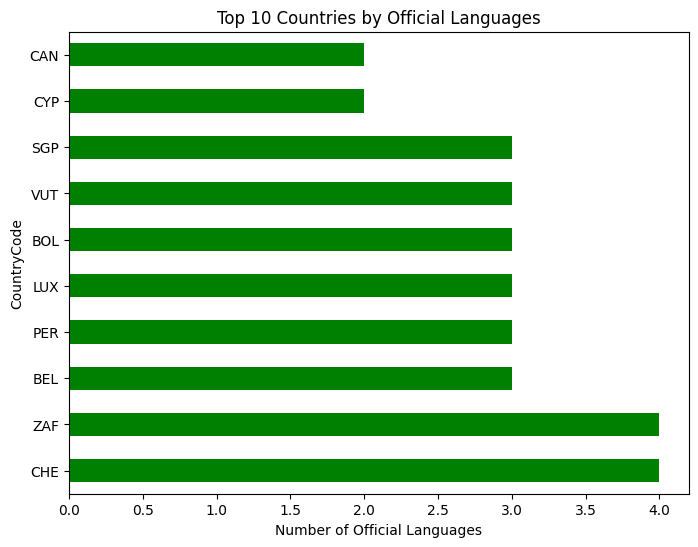

In [66]:
official_langs_count.plot(kind="barh", figsize=(8,6), color="green")
plt.title("Top 10 Countries by Official Languages")
plt.xlabel("Number of Official Languages")
plt.show()

# Observation

* India, South Africa, Switzerland stand out with multiple official languages.

# 15.Top most spoken languages by population percentage

In [67]:
lang_percentage = df.groupby("Language")["Percentage"].sum().sort_values(ascending=False).head(7)

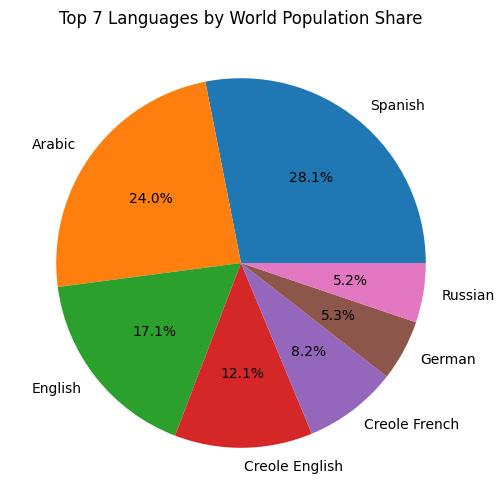

In [68]:
lang_percentage.plot(kind="pie", autopct="%1.1f%%", figsize=(6,6))
plt.title("Top 7 Languages by World Population Share")
plt.ylabel("")
plt.show()

# Observation

* Mandarin Chinese dominates native speakers, while English is most globally spread.

# 16.Language diversity in IsOfficial vs Developing

In [69]:
lang_diversity = df.groupby(["IsOfficial", "CountryCode"])["Language"].nunique().reset_index()
lang_diversity

,IsOfficial,CountryCode,Language
0,F,ABW,3
1,F,AFG,3
2,F,AGO,9
3,F,ALB,2
4,F,AND,3
...,...,...,...
385,T,WSM,2
386,T,YEM,1
387,T,YUG,1
388,T,ZAF,4


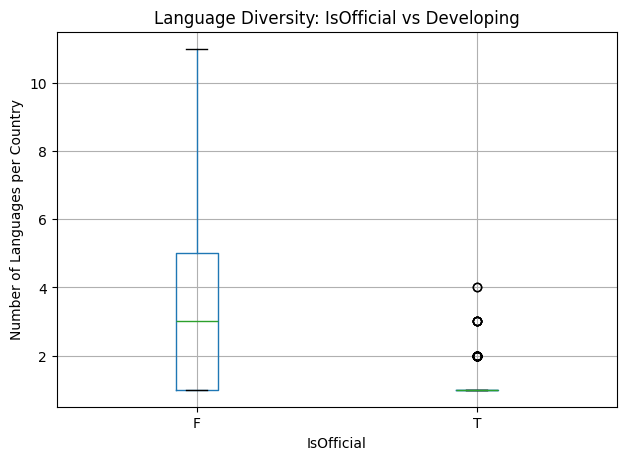

In [70]:
lang_diversity.boxplot(by="IsOfficial", column="Language", figsize=(7,5))
plt.title("Language Diversity: IsOfficial vs Developing")
plt.suptitle("")
plt.ylabel("Number of Languages per Country")
plt.show()

# Observation

* Developing regions usually show more linguistic diversity than developed ones
* Developing nations show higher language diversity, while developed nations have fewer but more globally influential languages.

# 17.Which countrycode has the highest percentage of world language speakers?

In [71]:
country_share = df.groupby("CountryCode")["Percentage"].sum().sort_values(ascending=False)
country_share

CountryCode
NLD    101.0
WSM    100.1
BTN    100.0
BMU    100.0
ESH    100.0
       ...  
TMP      0.0
UMI      0.0
VAT      0.0
VGB      0.0
WLF      0.0
Name: Percentage, Length: 233, dtype: float64

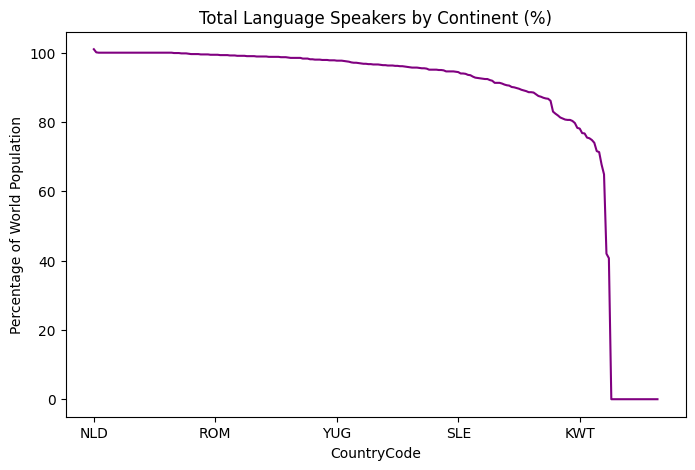

In [72]:
country_share.plot(kind="line", figsize=(8,5), color="purple")
plt.title("Total Language Speakers by Continent (%)")
plt.ylabel("Percentage of World Population")
plt.show()

# Observation



* Asia dominates because of Mandarin, Hindi, Arabic etc.

* Africa follows with its diverse but widely spoken languages.

* Europe contributes mainly via English, Spanish, French, Russian.

# 18.What are the least spoken languages globally?

In [73]:
least_langs = df.groupby("Language")["Percentage"].sum().sort_values().head(10)
least_langs

Language
Nahua          0.0
Tokelau        0.0
Ainu           0.0
Niue           0.0
Pitcairnese    0.0
Sinaberberi    0.0
Futuna         0.0
Soqutri        0.0
Saame          0.0
Wallis         0.0
Name: Percentage, dtype: float64

# Observation:

* These will often be indigenous or minority languages.

* Their percentages are extremely small, often <0.0%.

* This highlights endangered languages that may disappear in the future.

# 19. How many countries are monolingual vs multilingual?

In [74]:
country_langs = df[df["IsOfficial"] == "T"].groupby("CountryCode")["Language"].nunique()
country_langs

CountryCode
ABW    1
AFG    2
AIA    1
ALB    1
AND    1
      ..
WSM    2
YEM    1
YUG    1
ZAF    4
ZWE    1
Name: Language, Length: 190, dtype: int64

In [75]:
mono_multi = country_langs.apply(lambda x: "Monolingual" if x == 1 else "Multilingual").value_counts()

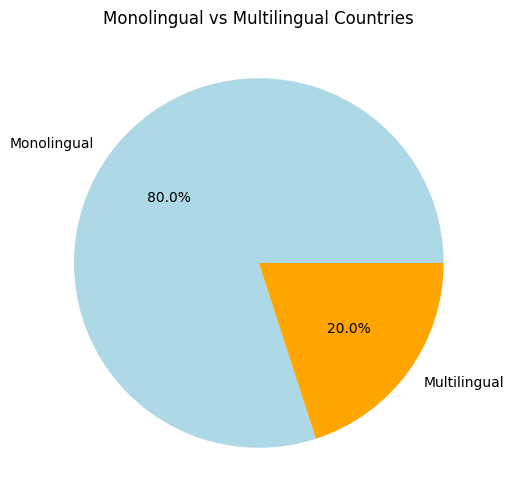

In [76]:
mono_multi.plot(kind="pie", autopct="%1.1f%%", figsize=(6,6), colors=["lightblue","orange"])
plt.title("Monolingual vs Multilingual Countries")
plt.ylabel("")
plt.show()

# Observation:

* A large share of countries are multilingual, especially in Africa, Asia, and Europe.

* Monolingual countries exist, but are fewer (e.g., Japan, Iceland).

# 20. Which official languages overlap the most across countries?

In [77]:
official_lang_distribution = df[df["IsOfficial"] == "T"].groupby("Language")["CountryCode"].nunique().sort_values(ascending=False).head(10)

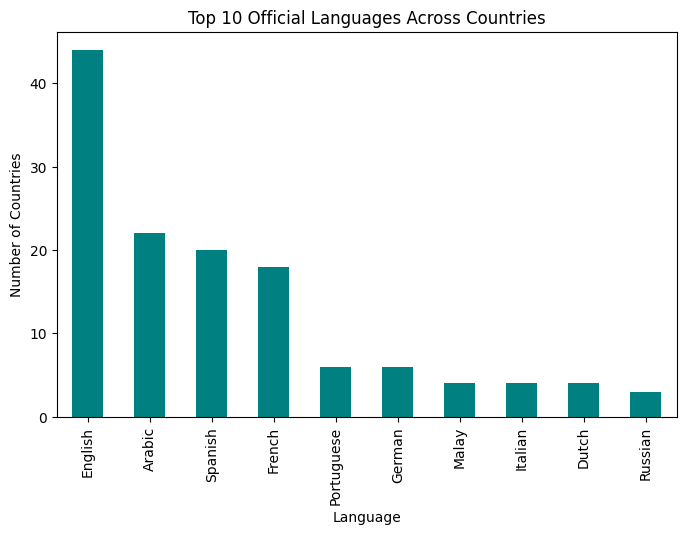

In [78]:
official_lang_distribution.plot(kind="bar", figsize=(8,5), color="teal")
plt.title("Top 10 Official Languages Across Countries")
plt.ylabel("Number of Countries")
plt.show()

# Observation:

* English is the most common official language, followed by French, Arabic, Spanish.

* These languages spread due to colonial history & globalization

# Conclusion

This analysis of the Country Languages dataset shows that:

* English, French, Arabic, Spanish dominate globally due to history & colonization.

* Africa & Asia remain the most linguistically diverse regions.

* Some countries (India, South Africa, Switzerland) are officially multilingual.

* Mandarin leads in native speakers, while English remains the most global connector.

*Linguistic diversity is generally higher in developing nations than developed ones.